# Mean Reversion Strategy Exploration (Simple Version)

This notebook explores the data and key components for implementing a mean reversion strategy. The strategy is based on statistical tests to identify mean-reverting behavior in price series, combined with machine learning to predict trend continuation when prices deviate significantly from the mean.

## 1. Setup and Data Loading

First, let's import the necessary libraries and load the data.

In [1]:
import os
import sys
from datetime import datetime, timedelta
from decimal import Decimal

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from scipy.optimize import minimize

# Set plotting style
plt.style.use('ggplot')
sns.set_style('whitegrid')

# Import Nautilus Trader components
from nautilus_trader.model.identifiers import InstrumentId, Symbol, Venue
from nautilus_trader.model.data import BarType, Bar
from nautilus_trader.persistence.catalog import ParquetDataCatalog

# Add the current directory to the Python path so we can import our strategy components
sys.path.append(os.getcwd())
sys.path.append(os.path.join(os.getcwd(), '..'))

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

### 1.1 Load Data from Catalog

We'll load the BTCUSDT data from the Nautilus Trader catalog.

In [2]:
# Define the symbol and timeframe
symbol = "BTCUSDT"
venue = "BINANCE"
timeframe = "1-HOUR"

# Create instrument ID
instrument_id = InstrumentId(Symbol(symbol), Venue(venue))

# Define the bar types
hourly_bar_type = BarType.from_str(f"{instrument_id.value}-{timeframe}-LAST-EXTERNAL")
daily_bar_type = BarType.from_str(f"{instrument_id.value}-1-DAY-LAST-EXTERNAL")

# Path to the catalog
catalog_path = "../data/catalog"

# Create the catalog
catalog = ParquetDataCatalog(catalog_path)

# Load the instrument
instruments = catalog.instruments(instrument_ids=[instrument_id.value])
if instruments:
    instrument = instruments[0]
    print(f"Loaded instrument: {instrument}")
else:
    print(f"Instrument {instrument_id} not found in catalog")
    # Create a dummy instrument for demonstration purposes
    from nautilus_trader.test_kit.providers import TestInstrumentProvider
    instrument = TestInstrumentProvider.btcusdt_binance()
    print(f"Created dummy instrument: {instrument}")

# Load the hourly bars
hourly_bars = catalog.bars(bar_types=[str(hourly_bar_type)])
print(f"Loaded {len(hourly_bars)} hourly bars")

# Filter bars for our instrument
hourly_bars = [bar for bar in hourly_bars if bar.bar_type.instrument_id == instrument_id]
print(f"Filtered to {len(hourly_bars)} hourly bars for {instrument_id}")

# Load the daily bars
daily_bars = catalog.bars(bar_types=[str(daily_bar_type)])
print(f"Loaded {len(daily_bars)} daily bars")

# Filter bars for our instrument
daily_bars = [bar for bar in daily_bars if bar.bar_type.instrument_id == instrument_id]
print(f"Filtered to {len(daily_bars)} daily bars for {instrument_id}")

Loaded instrument: CurrencyPair(id=BTCUSDT.BINANCE, raw_symbol=BTCUSDT, asset_class=CRYPTOCURRENCY, instrument_class=SPOT, quote_currency=USDT, is_inverse=False, price_precision=2, price_increment=0.01, size_precision=6, size_increment=0.000001, multiplier=1, lot_size=None, margin_init=0, margin_maint=0, maker_fee=0.001, taker_fee=0.001, info=None)
Loaded 720 hourly bars
Filtered to 720 hourly bars for BTCUSDT.BINANCE
Loaded 30 daily bars
Filtered to 30 daily bars for BTCUSDT.BINANCE


### 1.2 Convert Bars to DataFrames

Let's convert the bars to pandas DataFrames for easier analysis.

In [3]:
# Convert hourly bars to DataFrame
hourly_df = pd.DataFrame({
    "open": [bar.open.as_double() for bar in hourly_bars],
    "high": [bar.high.as_double() for bar in hourly_bars],
    "low": [bar.low.as_double() for bar in hourly_bars],
    "close": [bar.close.as_double() for bar in hourly_bars],
    "volume": [float(bar.volume) for bar in hourly_bars],
}, index=[pd.Timestamp(bar.ts_event / 1_000_000_000, unit='s') for bar in hourly_bars])

# Convert daily bars to DataFrame
daily_df = pd.DataFrame({
    "open": [bar.open.as_double() for bar in daily_bars],
    "high": [bar.high.as_double() for bar in daily_bars],
    "low": [bar.low.as_double() for bar in daily_bars],
    "close": [bar.close.as_double() for bar in daily_bars],
    "volume": [float(bar.volume) for bar in daily_bars],
}, index=[pd.Timestamp(bar.ts_event / 1_000_000_000, unit='s') for bar in daily_bars])

# Add log returns
hourly_df['log_price'] = np.log(hourly_df['close'])
hourly_df['log_return'] = hourly_df['log_price'].diff()

daily_df['log_price'] = np.log(daily_df['close'])
daily_df['log_return'] = daily_df['log_price'].diff()

# Display the first few rows of each DataFrame
print("Hourly Data:")
hourly_df.head()

Hourly Data:


,open,high,low,close,volume,log_price,log_return
2025-04-12 18:00:00,84760.71,85193.09,84755.50,85178.01,378.89539,11.352499,NaN
2025-04-12 19:00:00,85178.00,85258.29,84834.75,84943.40,468.33569,11.349740,-0.002758
2025-04-12 20:00:00,84943.39,85905.00,84877.61,85517.29,1116.86575,11.356474,0.006733
2025-04-12 21:00:00,85517.28,85566.28,85260.86,85367.93,620.78416,11.354726,-0.001748
2025-04-12 22:00:00,85367.93,85701.60,85329.27,85336.01,314.03061,11.354352,-0.000374


In [4]:
print("Daily Data:")
daily_df.head()

Daily Data:


,open,high,low,close,volume,log_price,log_return
2025-04-13,85276.91,86100.00,83034.23,83760.00,24680.04181,11.335711,NaN
2025-04-14,83760.00,85799.99,83678.00,84591.58,28659.09348,11.345590,0.009879
2025-04-15,84591.58,86496.42,83600.00,83643.99,20910.99528,11.334325,-0.011265
2025-04-16,83643.99,85500.00,83111.64,84030.38,20867.24519,11.338934,0.004609
2025-04-17,84030.38,85470.01,83736.26,84947.91,13728.84772,11.349794,0.010860


### 1.3 Visualize Price Data

Let's visualize the price data to get a better understanding of the market.

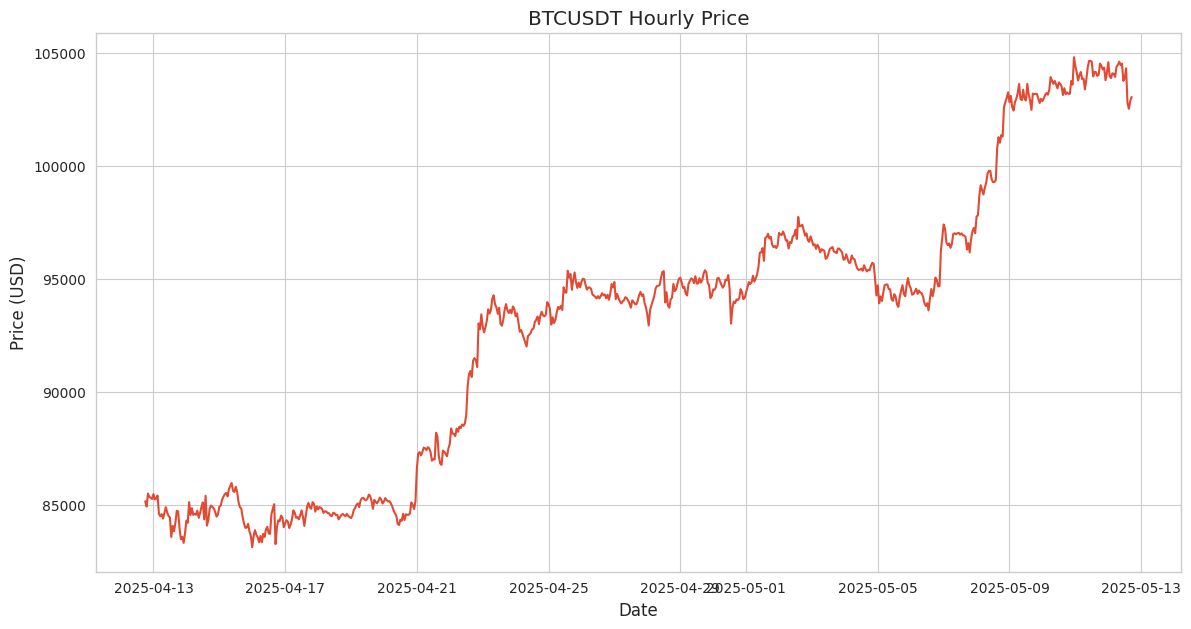

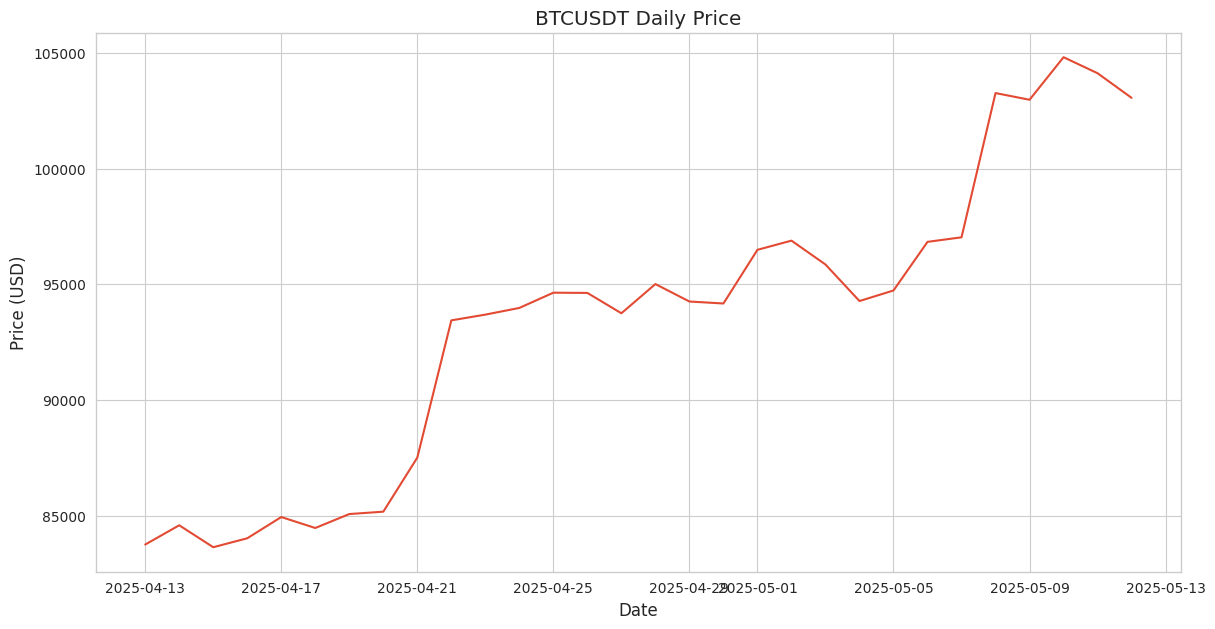

In [5]:
# Plot hourly price data
plt.figure(figsize=(14, 7))
plt.plot(hourly_df.index, hourly_df['close'])
plt.title(f'{symbol} Hourly Price')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.show()

# Plot daily price data
plt.figure(figsize=(14, 7))
plt.plot(daily_df.index, daily_df['close'])
plt.title(f'{symbol} Daily Price')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.show()

## 2. Stationarity Testing

A key component of the mean reversion strategy is testing for stationarity using the Augmented Dickey-Fuller (ADF) test. Let's implement this test and visualize the results.

Using lookback window of 168 hours


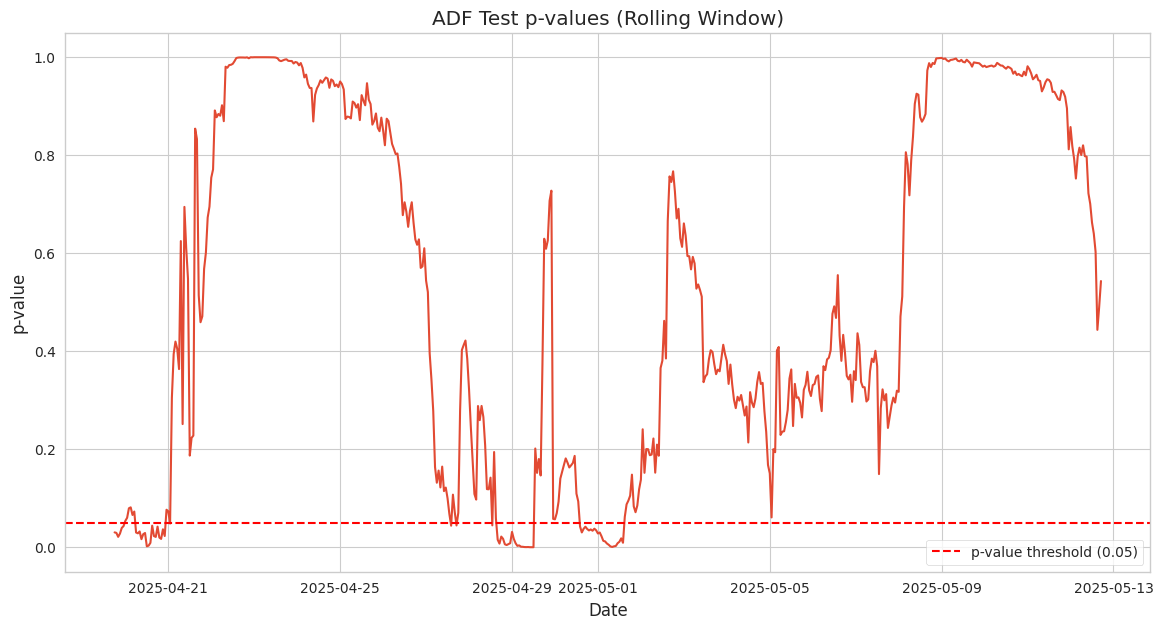

Percentage of stationary windows: 13.22%


In [6]:
def run_adf_test(prices, window=168):
    """
    Run the Augmented Dickey-Fuller test on a rolling window of prices.
    
    Parameters
    ----------
    prices : array-like
        The price series to test.
    window : int
        The size of the rolling window (default: 168 hours = 7 days).
        
    Returns
    -------
    tuple
        (p_values, statistics) for each window.
    """
    p_values = []
    statistics = []
    
    # Adjust window size if we don't have enough data
    window = min(window, len(prices) // 2)
    
    for i in range(window, len(prices)):
        # Get the window of prices
        window_prices = prices[i-window:i]
        
        # Run the ADF test
        result = adfuller(window_prices)
        
        # Store the results
        p_values.append(result[1])
        statistics.append(result[0])
    
    return p_values, statistics

# Run the ADF test on the log prices
lookback = min(168, len(hourly_df) // 3)  # Adjust lookback based on available data
print(f"Using lookback window of {lookback} hours")

p_values, statistics = run_adf_test(hourly_df['log_price'].values, window=lookback)

# Create a DataFrame with the results
adf_df = pd.DataFrame({
    'p_value': p_values,
    'statistic': statistics,
    'is_stationary': [p < 0.05 for p in p_values],  # p-value < 0.05 indicates stationarity
}, index=hourly_df.index[lookback:])

# Plot the p-values
plt.figure(figsize=(14, 7))
plt.plot(adf_df.index, adf_df['p_value'])
plt.axhline(y=0.05, color='r', linestyle='--', label='p-value threshold (0.05)')
plt.title('ADF Test p-values (Rolling Window)')
plt.xlabel('Date')
plt.ylabel('p-value')
plt.legend()
plt.grid(True)
plt.show()

# Calculate the percentage of stationary windows
stationary_pct = adf_df['is_stationary'].mean() * 100
print(f"Percentage of stationary windows: {stationary_pct:.2f}%")

## 3. Technical Indicators

Let's calculate and visualize the technical indicators used in the strategy.

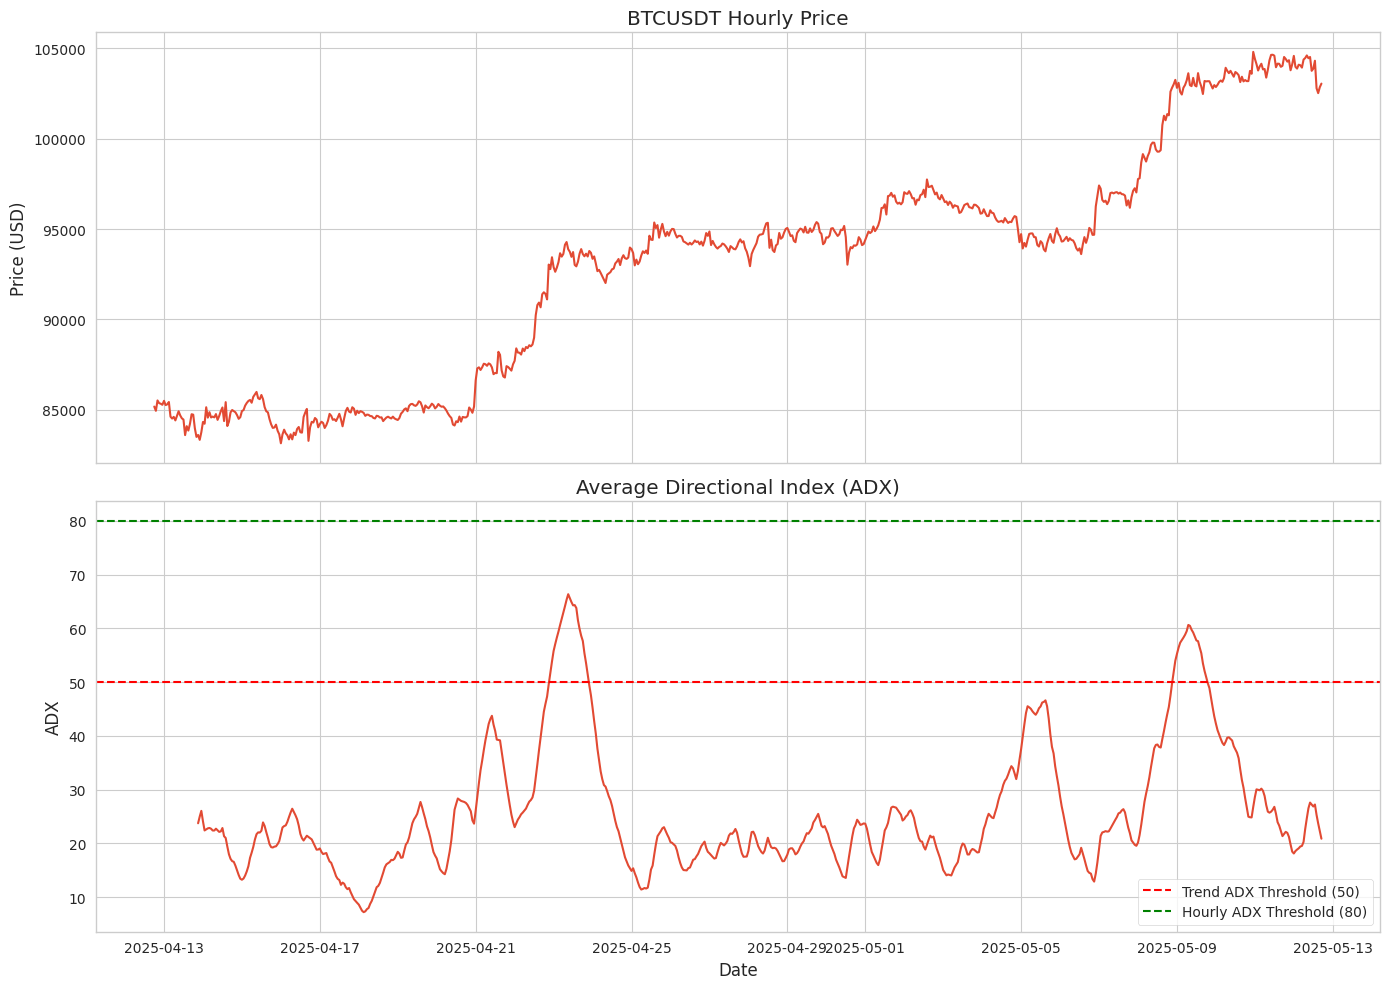

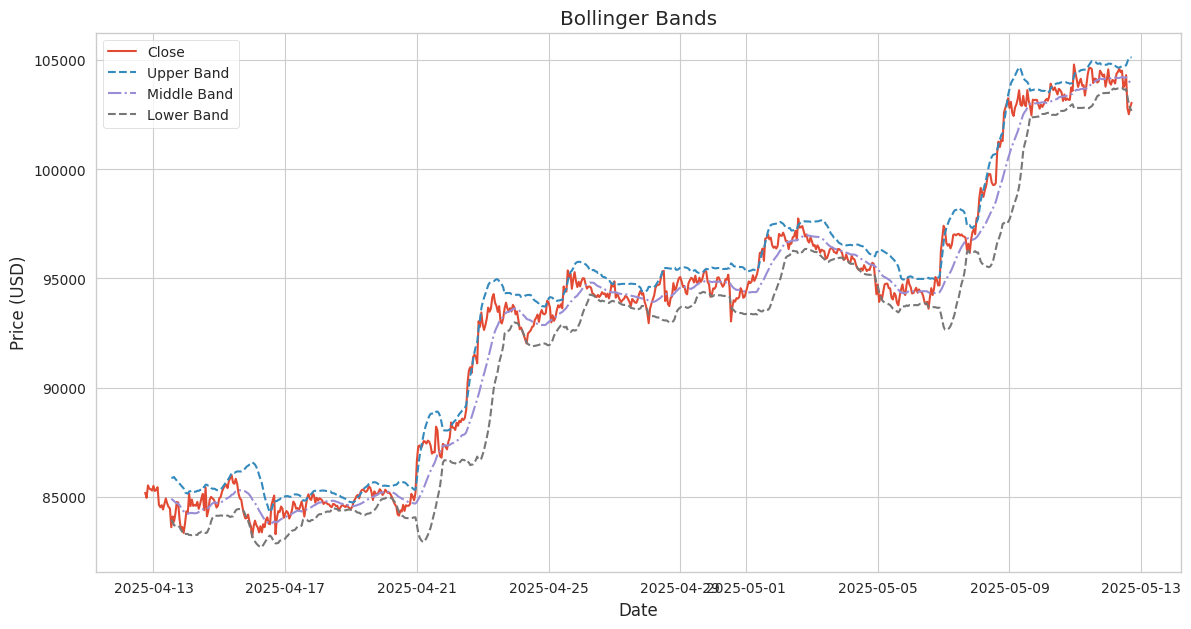

In [7]:
# Install pandas_ta if not already installed
import pandas_ta as ta

# Calculate indicators for hourly data
hourly_df['adx'] = ta.adx(hourly_df['high'], hourly_df['low'], hourly_df['close'], length=14)['ADX_14']
hourly_df['rsi'] = ta.rsi(hourly_df['close'], length=14)
macd = ta.macd(hourly_df['close'], fast=12, slow=26, signal=9)
hourly_df['macd'] = macd['MACD_12_26_9']
hourly_df['macd_signal'] = macd['MACDs_12_26_9']
hourly_df['macd_hist'] = macd['MACDh_12_26_9']
bbands = ta.bbands(hourly_df['close'], length=20, std=2)
hourly_df['bb_upper'] = bbands['BBU_20_2.0']
hourly_df['bb_middle'] = bbands['BBM_20_2.0']
hourly_df['bb_lower'] = bbands['BBL_20_2.0']
hourly_df['atr'] = ta.atr(hourly_df['high'], hourly_df['low'], hourly_df['close'], length=14)

# Calculate indicators for daily data
daily_df['adx'] = ta.adx(daily_df['high'], daily_df['low'], daily_df['close'], length=14)['ADX_14']

# Plot the ADX indicator
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

axes[0].plot(hourly_df.index, hourly_df['close'])
axes[0].set_title(f'{symbol} Hourly Price')
axes[0].set_ylabel('Price (USD)')
axes[0].grid(True)

axes[1].plot(hourly_df.index, hourly_df['adx'])
axes[1].axhline(y=50, color='r', linestyle='--', label='Trend ADX Threshold (50)')
axes[1].axhline(y=80, color='g', linestyle='--', label='Hourly ADX Threshold (80)')
axes[1].set_title('Average Directional Index (ADX)')
axes[1].set_ylabel('ADX')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Plot the Bollinger Bands
plt.figure(figsize=(14, 7))
plt.plot(hourly_df.index, hourly_df['close'], label='Close')
plt.plot(hourly_df.index, hourly_df['bb_upper'], label='Upper Band', linestyle='--')
plt.plot(hourly_df.index, hourly_df['bb_middle'], label='Middle Band', linestyle='-.')
plt.plot(hourly_df.index, hourly_df['bb_lower'], label='Lower Band', linestyle='--')
plt.title('Bollinger Bands')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

## 4. Conclusion

In this notebook, we've explored the key components of the mean reversion strategy:

1. **Stationarity Testing**: We used the Augmented Dickey-Fuller (ADF) test to identify periods when the price series exhibits mean-reverting behavior.

2. **Technical Indicators**: We calculated and visualized various technical indicators used in the strategy, including ADX, RSI, MACD, Bollinger Bands, and ATR.

This exploration provides a foundation for implementing and backtesting the mean reversion strategy. The next steps would be to:

1. Implement the Ornstein-Uhlenbeck parameter estimation
2. Implement the grid trading levels visualization
3. Implement the machine learning feature exploration
4. Implement the regime switching analysis
5. Implement the full strategy in the Nautilus Trader framework
6. Backtest the strategy with different parameter settings
7. Optimize the parameters to improve performance
8. Evaluate the strategy's performance in different market conditions